In [1]:
from libMilne import *
import os
from concurrent.futures import ProcessPoolExecutor
fmToGeV = 1/0.197327

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1078: SyntaxWarning: invalid escape sequence '\s'
  """
/home/andrea/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
"""
    In this cell we get the entire grids for the integrands of energy density, pressure, spin density and spin torque using the exact diagonalization
    of the canonical pseudogauge with a fixed spin potential. We expect that for a small spin potential the values will be comparable with those
    obtained in the Belinfante pseudogauge.
    
    In order to have a symmetric grid of integration the range of px and py should be the same while the range of mu is computed
    from the relation mu=tau*pz with pz_max=px_max.

    Reduce N to accelerate the calculation.
"""


# Parameters
mass = 1.0
tau = 1.0
Temp = 1.0
beta = 1.0/Temp
SP = 1e-5
mu_T = 0.0

# Integration limit (Symmetric cubic grid)
px_min, px_max = -10.0, 10.0
py_min, py_max = -px_max, px_max
mu_min, mu_max = -px_max*tau, px_max*tau 

# Number of points per dimension
N = 20  

# Create grid. This function creates a grid which is denser around the middle point of the interval (in this case, the origin)
mu_grid = middle_dense_grid(N, mu_min, mu_max)
px_grid = middle_dense_grid(N, px_min, px_max)
py_grid = middle_dense_grid(N, py_min, py_max)

# Initialize 3D array
integrand_gridE = np.zeros((N, N, N))
integrand_gridPT = np.zeros((N, N, N))
integrand_gridPL = np.zeros((N, N, N))
integrand_gridS = np.zeros((N, N, N))
integrand_gridT = np.zeros((N, N, N))

# Loop over grid points
for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            resE,resPT,resPL, resS, resT = tabulating_canonical(
                mass, px, py, mu, tau, beta, SP, mu_T, precision=80
            )
            integrand_gridE[i,j,k] = float(to_numpy(resE))
            integrand_gridPT[i,j,k] = float(to_numpy(resPT))
            integrand_gridPL[i,j,k] = float(to_numpy(resPL))
            integrand_gridS[i,j,k] = float(to_numpy(resS))
            integrand_gridT[i,j,k] = float(to_numpy(resT))

# Integration            
_ = simpson(integrand_gridE, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
E_can = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridPT, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
PT_can = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridPL, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
PL_can = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridT, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
Torque = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridS, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
SpinDens = simpson(_, x=py_grid, axis=0)

print(f"Integral E result SP = {SP}: ", E_can)
print(f"Integral PT result SP = {SP}: ", PT_can)
print(f"Integral PL result SP = {SP}: ", PL_can)
print(f"Integral S result SP = {SP}: ", SpinDens)
print(f"Integral T result SP = {SP}: ", Torque)


/tmp/ipykernel_58827/1374301078.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridE[i,j,k] = float(to_numpy(resE))
/tmp/ipykernel_58827/1374301078.py:49: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPT[i,j,k] = float(to_numpy(resPT))
/tmp/ipykernel_58827/1374301078.py:50: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPL[i,j,k] = float(to_numpy(resPL))
/tmp/ipykernel_58827/1374301078.py:51: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridS[i,j,k] = float(to_numpy(resS))
/tmp/ipykernel_58827/1374301078.py:52: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridT[i,j,k] = float(to_numpy(resT))


Integral E result SP = 1e-05:  1.0571259987467807
Integral PT result SP = 1e-05:  0.3157380899528235
Integral PL result SP = 1e-05:  0.31573808995281116
Integral S result SP = 1e-05:  -1.6848944021839794e-07
Integral T result SP = 1e-05:  -5.9649233329588375e-15


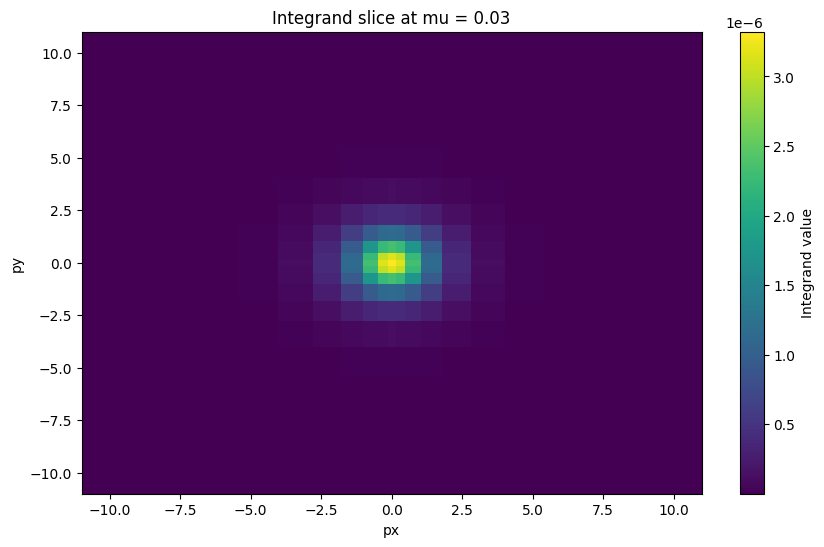

In [3]:
"""
    You can check the integrands by plotting slices like in this cell
"""

plot_integrand_slice(integrand_gridPL, mu_grid, px_grid, py_grid, x_axis=1,y_axis=2)

In [4]:
"""
    We can compare the previous results with those obtained with the same method and grid with the analytic formulae at SP=0 in the belinfante pseudogauge.
    We can also evaluate the results from the partition function.
"""

integrand_gridBELE = np.zeros((N, N, N))
integrand_gridBELPT = np.zeros((N, N, N))
integrand_gridBELPL = np.zeros((N, N, N))
integrandLogZ_P = np.zeros((N, N, N))
integrandLogZ_S = np.zeros((N, N, N))


for i, mu in enumerate(mu_grid):
    for j, px in enumerate(px_grid):
        for k, py in enumerate(py_grid):
            resE,resPT,resPL = tabulating_belinfante(
                mass, px, py, mu, tau, beta, precision=50
            )
            integrand_gridBELE[i, j, k],integrand_gridBELPT[i, j, k],integrand_gridBELPL[i, j, k] = float(to_numpy(resE)),float(to_numpy(resPT)),float(to_numpy(resPL))
            integrandLogZ_P[i,j,k], integrandLogZ_S[i,j,k], _ = tabulating_logZ(mass, px, py, mu, tau, beta, SP, precision = 50)
            
_ = simpson(integrand_gridBELE, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
E_bel = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridBELPT, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
PT_bel = simpson(_, x=py_grid, axis=0)

_ = simpson(integrand_gridBELPL, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
PL_bel = simpson(_, x=py_grid, axis=0)

_ = simpson(integrandLogZ_P, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
ZPres = simpson(_, x=py_grid, axis=0)

_ = simpson(integrandLogZ_S, x=mu_grid, axis=0)
_ = simpson(_, x=px_grid, axis=0)
Zentr = simpson(_, x=py_grid, axis=0)

print("Integral E result belinfante: ", E_bel)
print("Integral PT result belinfante: ", PT_bel)
print("Integral PL result belinfante: ", PL_bel)
print("Integral E from logZ: ", -ZPres+Temp*Zentr)
print("Integral P from logZ: ", ZPres)

/tmp/ipykernel_58827/2514899310.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridBELE[i, j, k],integrand_gridBELPT[i, j, k],integrand_gridBELPL[i, j, k] = float(to_numpy(resE)),float(to_numpy(resPT)),float(to_numpy(resPL))


Integral E result belinfante:  1.0571259987449229
Integral PT result belinfante:  0.3157380899519805
Integral PL result belinfante:  0.31573808995198055
Integral E from logZ:  1.057017320976984
Integral P from logZ:  0.31694565740891717


## Evaluate in parallel for different values of Spin potential

In [5]:
"""
    Here we perform a parallel evaluation of the integrals using nproc processors for a list of Spin potentials. Each value of SP will be handeled
    by a different processor. Make sure the output_dir exists before executing this cell. 
    
    This is evalueted by default on a small grid. Increase N to gain precision. If you test other values of mass, tau and Temp, make sure that the
    cuts in the domain are adequate and the precision used to evaluate Hankel functions is sufficient.
    
    In the current form, this cell should run in ~ 3 mins. Increase N to improve precision.
"""
nproc = 6

output_dir="./test"
# Parameters
mass = 1.0
tau = 1.0
Temp = 1.0
beta = 1.0 / Temp
Omlist = np.linspace(1e-5,3,6) ## This is a list in Omega, SP=Om*beta
mu_T = 0.0


# Integration limits and grid
mu_min, mu_max = -20.0, 20.0
px_min, px_max = -20.0, 20.0
py_min, py_max = -20.0, 20.0
N = 20

mu_grid = middle_dense_grid(N, mu_min, mu_max)
px_grid = middle_dense_grid(N, px_min, px_max)
py_grid = middle_dense_grid(N, py_min, py_max)


with ProcessPoolExecutor(max_workers=nproc) as executor:
    futures = [executor.submit(
        process_Om_tofile,
        Om, mass, tau, beta, mu_T, mu_grid, px_grid, py_grid, output_dir=output_dir
    ) for Om in Omlist]  # this function creates a file for each value of Om, containing, Om, E, PT, PL, Spin_dens, Torque 

    for future in futures:
        res = future.result()
        print(f"Saved results for Om = {res[0]}")
        
joinSPfiles(output_dir,mass,beta,tau,mu_T) #This function joins all the files in the output dir, for a more comfortable plotting

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1311: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridE[i,j,k] = float(to_numpy(resE))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1312: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridPT[i,j,k] = float(to_numpy(resPT))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1311: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridE[i,j,k] = float(to_numpy(resE))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1311: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridE[i,j,k] = float(to_numpy(resE))
/home/andrea/Desktop/Università/Work/Artic

Saved results for Om = 1e-05
Saved results for Om = 0.600008
Saved results for Om = 1.2000060000000001
Saved results for Om = 1.8000040000000002
Saved results for Om = 2.400002
Saved results for Om = 3.0


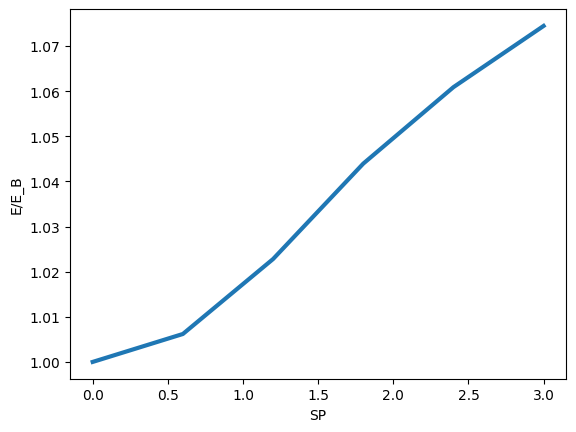

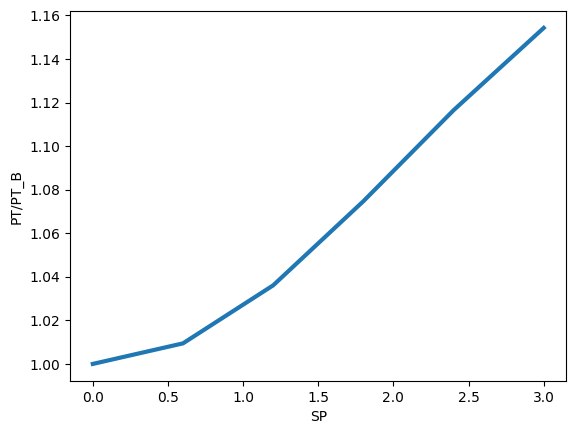

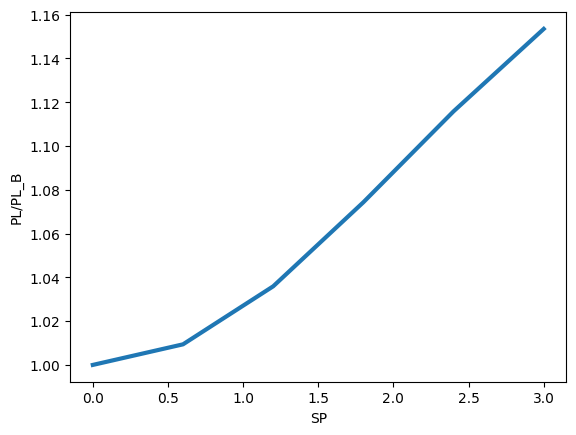

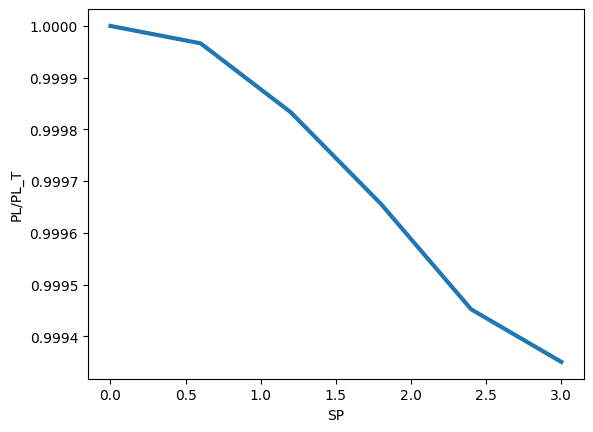

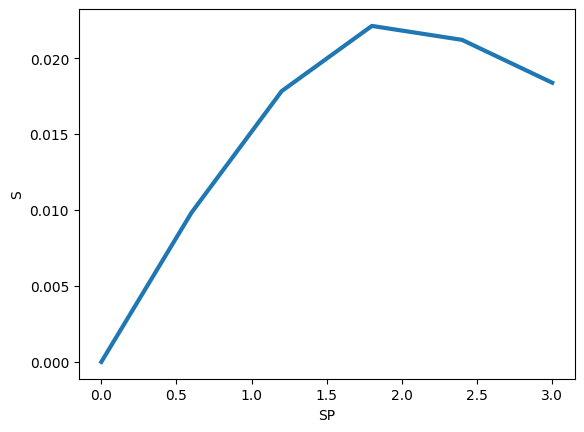

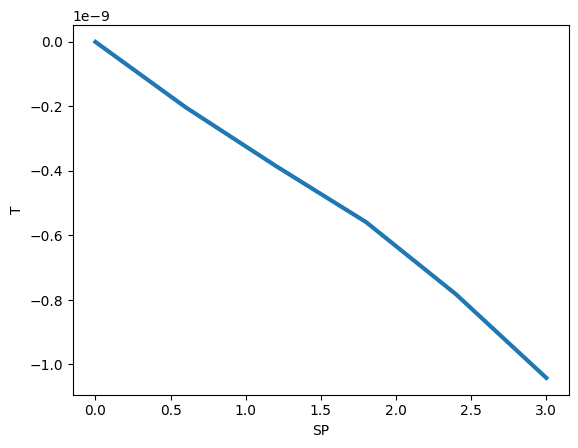

In [24]:
"""
    Now you can read the results of the resulting file and plot them
"""

theOmlist, Elist, PTlist, PLlist,Slist,Tlist = np.loadtxt(f"{output_dir}/joined_mass={1.0}_Temp={Temp}_tau={tau}_mu_T={mu_T}.txt")

plt.figure()
plt.plot(theOmlist, Elist/Elist[0], linewidth=3)
plt.xlabel("SP")
plt.ylabel("E/E_B")

# Plot 2
plt.figure()
plt.plot(theOmlist, PTlist/PTlist[0], linewidth=3)
plt.xlabel("SP")
plt.ylabel("PT/PT_B")

plt.figure()
plt.plot(theOmlist, PLlist/PLlist[0], linewidth=3)
plt.xlabel("SP")
plt.ylabel("PL/PL_B")

plt.figure()
plt.plot(theOmlist, PLlist/PTlist, linewidth=3)
plt.xlabel("SP")
plt.ylabel("PL/PL_T")

plt.figure()
plt.plot(theOmlist, Slist, linewidth=3)
plt.xlabel("SP")
plt.ylabel("S")

plt.figure()
plt.plot(theOmlist, Tlist, linewidth=3)
plt.xlabel("SP")
plt.ylabel("T")

plt.show()

In [22]:
"""
    You can also check the results of logZ. 
    
    This cell runs in ~ seconds
"""

# Parameters
mass = 1
tau = 1.0
Temp = 1.0
beta = 1.0/Temp
SPlist = np.linspace(1e-5,3,6)
mu_T = 0.0

# Integration limits
mu_min, mu_max = -20.0, 20.0
px_min, px_max = -20.0, 20.0
py_min, py_max = -20.0, 20.0

# Number of points per dimension
N = 40  # Adjust for speed/resolution

# Create grid
mu_grid = middle_dense_grid(N, mu_min, mu_max)
px_grid = middle_dense_grid(N, px_min, px_max)
py_grid = middle_dense_grid(N, py_min, py_max)

Elist = np.array([])
PTlist = np.array([])
PLlist = np.array([])
Slist = np.array([])
Tlist = np.array([])

with ProcessPoolExecutor(max_workers=nproc) as executor:
    results = list(executor.map(
        process_logZ,
        SPlist,
        [mass]*len(SPlist),
        [tau]*len(SPlist),
        [beta]*len(SPlist),
        [mu_grid]*len(SPlist),
        [px_grid]*len(SPlist),
        [py_grid]*len(SPlist),
    ))


Plist, P_dTlist, SlistZ = zip(*results)

# Update your lists
Plist = np.array(Plist)
P_dTlist = np.array(P_dTlist)
SlistZ = np.array(SlistZ)

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1274: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridP[i,j,k] = float(to_numpy(resP))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1274: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridP[i,j,k] = float(to_numpy(resP))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1274: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridP[i,j,k] = float(to_numpy(resP))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1274: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridP[i,j,k] = float(to_numpy(resP))
/home/andrea/Desktop/Università/Work/Articol

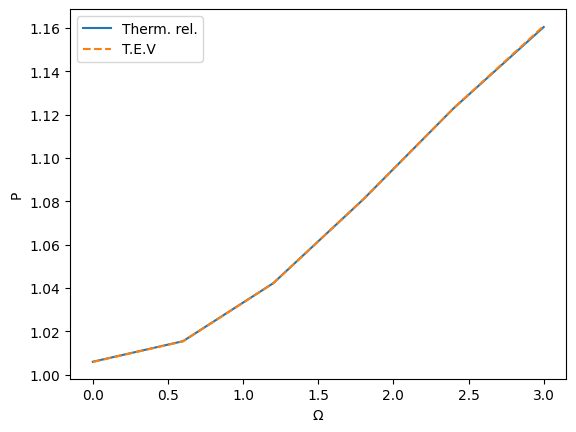

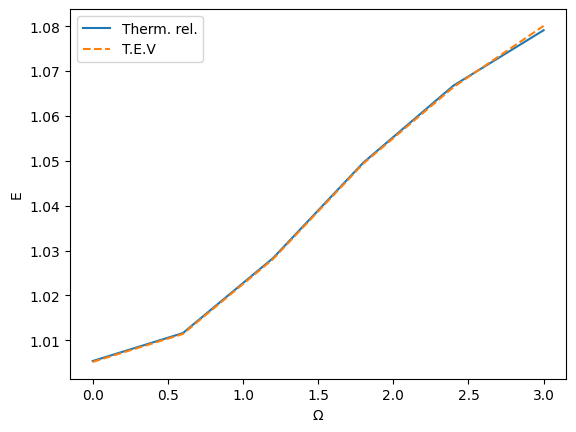

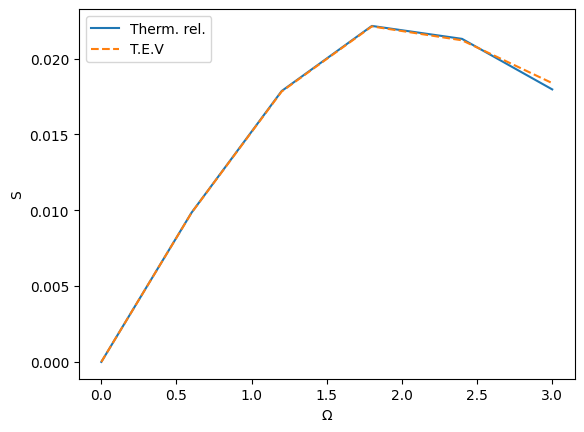

In [28]:
plt.figure()
plt.plot(SPlist,Plist/PT_bel,label="Therm. rel.")
plt.plot(SPlist,(PTlist)/PT_bel,linestyle="--",label="T.E.V")
plt.ylabel("P")
plt.xlabel(r"$\Omega$")
plt.legend()

plt.figure()
plt.plot(SPlist,(-Plist+Temp*P_dTlist+SPlist*SlistZ)/E_bel,label="Therm. rel.")
plt.plot(SPlist,(Elist)/E_bel,linestyle="--",label="T.E.V")
plt.ylabel("E")
plt.xlabel(r"$\Omega$")
plt.legend()

plt.figure()
plt.plot(SPlist,SlistZ,label="Therm. rel.")
plt.plot(SPlist,(Slist),linestyle="--",label="T.E.V")
plt.ylabel("S")
plt.xlabel(r"$\Omega$")
plt.legend()

## Polarization

In [8]:
"""
    Now we can evaluate polarization. In this case we do it for a realistic Lambda particle, so we need a much larger mu interval and a larger precision.
    
    Luckily, we only need to integrate in mu, so it's not that bad. This cell runs in ~1 min
"""

# Parameters
mass = 1.167
tau = 10.0*fmToGeV
Temp = 0.15
beta = 1.0/Temp
Omegalist = np.linspace(1e-5,3,12)
SPlist = 1/Temp*Omegalist
mu_T = 0.0
px = 0.1
py = 0

# Integration limits
mu_min, mu_max = -60, 60.0

# Number of points per dimension
N = 100  # Adjust for speed/resolution
# prec = 300

with ProcessPoolExecutor(max_workers=6) as executor:
    polarization_list = list(executor.map(process_Polarization, SPlist,
                                            [mass]*len(SPlist),
                                            [px]*len(SPlist),
                                            [py]*len(SPlist),
                                            [tau]*len(SPlist),
                                            [beta]*len(SPlist),
                                            [mu_T]*len(SPlist),
                                            [mu_min]*len(SPlist),
                                            [mu_max]*len(SPlist),
                                            [N]*len(SPlist)
    ))  
   

/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1352: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridD[i] = float(to_numpy(resD))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridZ[i] = float(to_numpy(resZ))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1352: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridD[i] = float(to_numpy(resD))
/home/andrea/Desktop/Università/Work/Articoli/polarization Milne/DiracFermions-in-MilneSpacetime/libMilne.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  integrand_gridZ[i] = float(to_numpy(resZ))
/home/andrea/Desktop/Università/Work/Articoli/polarization M

In [9]:
"""
    For pT=0 we can also evaluate using the analytic formula...
"""

exactlist = []
for Om in Omegalist:
    exactlist.append(exact_polarization_longitudinal(mass, tau, beta, Om/Temp, precision = 50))      

Text(0, 0.5, '$P_z$ [Gev]')

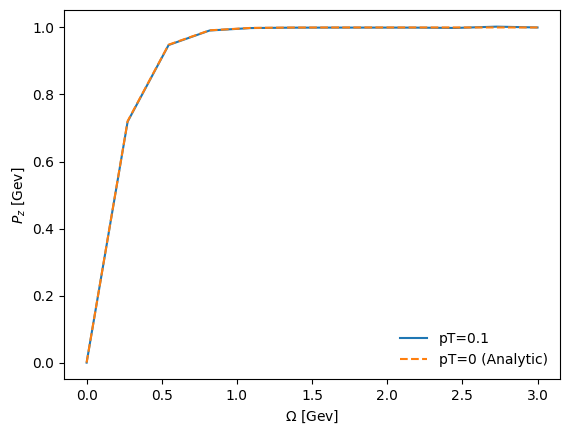

In [ ]:
"""
    ... and we can can compare the results.
"""

plt.plot(Omegalist, polarization_list, label=f"pT={np.sqrt(px**2+py**2)}")
plt.plot(Omegalist, exactlist,linestyle="--", label=f"pT=0 (Analytic)")

plt.legend(frameon=False)
plt.xlabel(r"$\Omega$ [Gev]")
plt.ylabel(r"$P_z$")